In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy import stats
from glob import glob
import torch.nn.functional as F
import torch
import datetime, os

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

In [117]:
FILTER_SE_GENES = False # filter for only genes with SE events
FILTER_EVENT_GENES = False # filter for genes with SE or AR events
SINGLE_COUNT_GENES = True # average out predictions per gene_id
HURDLE_SEPARATION = False # separate 1 values from the rest of the psi predictions
NORMALISED_SCORES = False # show uncorrected scores when they were z-score normalised
BOTH_CELL_LINES = False # separate predictions for both cell lines

In [118]:
def get_predictions(date_folder):
    # find .csv file in the date folder
    # first find the day folder where the exact model folder is located
    day_folder = date_folder[:10]  # e.g., '2025-07-25'
    csv_files = [f for f in glob(f"../trained_models/{day_folder}/{date_folder}/*.csv") if not f.endswith('losses.csv')]
    loss_file = [f for f in glob(f"../trained_models/{day_folder}/{date_folder}/*losses.csv")][0]
    losses = pd.read_csv(loss_file)
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {date_folder}")
    if len(csv_files) == 1:
        return pd.read_csv(csv_files[0]), losses
    else:
        all_predictions = []
        for pred_file in csv_files:
            df = pd.read_csv(pred_file)
            #if 'Unnamed: 0' in df.columns:
            #    df = df.drop(columns=['Unnamed: 0'])
            all_predictions.append(df)
        return pd.concat(all_predictions, ignore_index=True), losses
    
def find_folder(date_folder):
        # if date_folder is 'newest', find the most recent date folder
    if date_folder == 'newest':
        directory = "../trained_models/"
        newest_day = max([os.path.join(directory,d) for d in os.listdir(directory)], key=os.path.getmtime)
        newest_model = max([os.path.join(newest_day, d) for d in os.listdir(newest_day)], key=os.path.getmtime)
        date_folder = newest_model.split('/')[-1]
    print(f"Using date folder: {date_folder}")
    return date_folder


In [119]:
date_folder = find_folder('2025-08-26-10-23')

predictions, losses = get_predictions(date_folder)
predictions = predictions.rename(columns={'Unnamed: 0': 'gene_id', 'Pred': 'PredExpr', 'actual': 'ActualExpr'})
predictions

Using date folder: 2025-08-26-10-23


,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx
0,ENSG00000002016,1.313719,1.010724,GM12878,0.898365,1.000,1
1,ENSG00000002016,1.233347,1.010724,GM12878,0.920559,1.000,1
2,ENSG00000002016,0.964811,1.010724,GM12878,0.728862,0.208,1
3,ENSG00000002016,1.411281,1.010724,GM12878,0.845089,0.000,1
4,ENSG00000003056,1.894137,1.940716,GM12878,0.915052,1.000,1
...,...,...,...,...,...,...,...
3089,ENSG00000257390,0.846377,-0.552842,GM12878,0.893040,1.000,1
3090,ENSG00000257727,1.605636,2.163400,GM12878,0.925916,1.000,1
3091,ENSG00000257921,1.830481,-0.136677,GM12878,0.676849,1.000,1
3092,ENSG00000258311,1.615263,0.096910,GM12878,0.892272,1.000,1


In [120]:
if FILTER_SE_GENES:
    # filter predictions to the ones we have SE events for
    se_events = pd.read_csv('../data/psi_response.csv')
    se_events = se_events[se_events['event_id'].str.contains(';SE:')]
    se_genes = set(se_events['gene_id'].unique())

    # filter down predictions to only those genes
    predictions_filtered = predictions[predictions['gene_id'].isin(se_genes)]
    len(predictions_filtered)

if FILTER_EVENT_GENES:
    se_events = pd.read_csv('../data/psi_response.csv')
    se_events = set(se_events['gene_id'].unique())
    print(len(se_events), "genes with SE or AR events")

    predictions_filtered = predictions[predictions['gene_id'].isin(se_events)]
    print(len(predictions_filtered), "predictions for genes with SE or AR events")

In [121]:
if SINGLE_COUNT_GENES:
    # filter the predictions such that for one gene, we average out the predictions
    if FILTER_SE_GENES:
        predictions_filtered = predictions_filtered.groupby('gene_id').mean().reset_index()
    else:
        predictions_filtered = predictions.drop_duplicates(subset=['gene_id'], keep='first')

In [122]:
if not FILTER_SE_GENES and not SINGLE_COUNT_GENES and not FILTER_EVENT_GENES:
    predictions_filtered = predictions

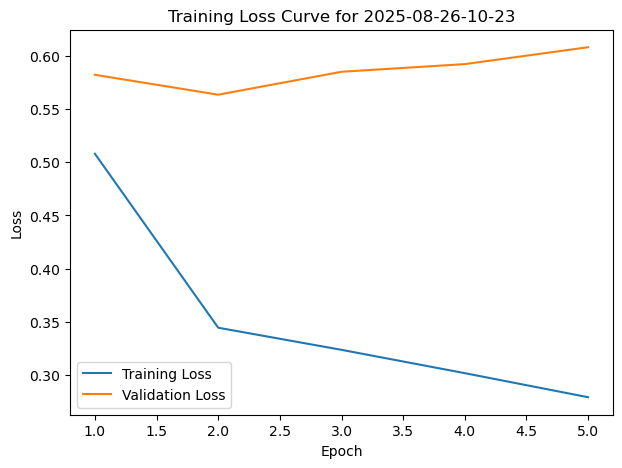

In [123]:
# plot loss curve
# cols: fold,epoch,training_loss,train_expr_loss,train_splice_loss,val_mse,val_r2,val_loss,val_expr,val_splice
plt.figure(figsize=(7, 5))
plt.plot(losses['epoch'], losses['training_loss'], label='Training Loss')
plt.plot(losses['epoch'], losses['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.yscale('log')  # Use logarithmic scale for better visibility
plt.title(f'Training Loss Curve for {date_folder}')
plt.legend()
plt.show()

In [124]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    r2_value = r2_score(predictions[actual_col], predictions[pred_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Pred (Pearson R: {pearsonR:.2f}, R²: {r2_value:.2f}, n={len(predictions)})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    #if prediction_task == 'PSI':
    #    plt.xlim(-0.1, 1.1)
    #    plt.ylim(-0.1, 1.1)
    #else:
    #    plt.xlim(-1, 5)
    #    plt.ylim(-1, 5)
    plt.tight_layout()
    
def plot_confusion_matrix(predictions, cell_line, pred_col, actual_col):
    confusion_matrix = pd.crosstab(predictions[pred_col], predictions[actual_col])
    
    plt.figure(figsize=(6,6))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{cell_line} Confusion Matrix")
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()

K562


<Figure size 600x600 with 0 Axes>

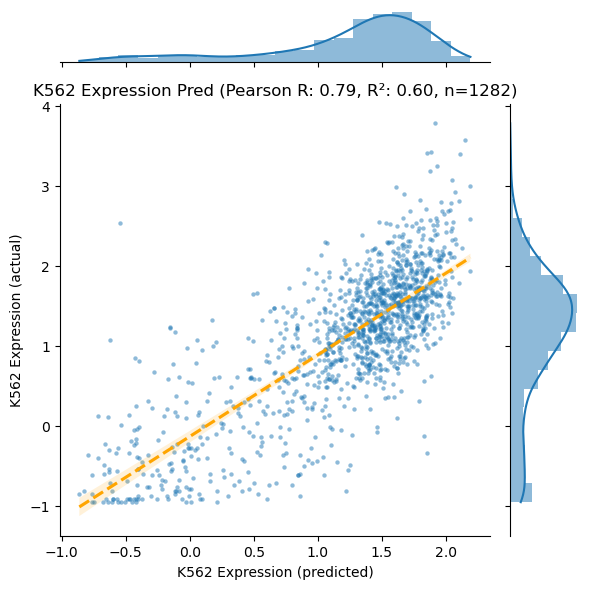

In [125]:
cell_line = 'K562' if not BOTH_CELL_LINES else 'K562/GM12878'
print(cell_line)
plot_predictions(predictions_filtered, cell_line=cell_line, pred_col='PredExpr', actual_col='ActualExpr')
plt.show()

In [126]:
if BOTH_CELL_LINES:
    plot_predictions(predictions_filtered[predictions_filtered['CellLine'] == 'K562'], cell_line='K562', pred_col='PredExpr', actual_col='ActualExpr')
    plot_predictions(predictions_filtered[predictions_filtered['CellLine'] == 'GM12878'], cell_line='GM12878', pred_col='PredExpr', actual_col='ActualExpr')

In [127]:
predictions_psi_filtered = None
binary_predictions = None
if HURDLE_SEPARATION:
    binary_predictions = predictions.copy()
    # convert all numbers that are not 1 to zero
    binary_predictions['PredPsi'] = np.where(binary_predictions['PredPsi'] == 1, "1", "0-0.99")
    binary_predictions['ActualPsi'] = np.where(binary_predictions['ActualPsi'] == 1, "1", "0-0.99")

    # predictions_psi_filtered = predictions[binary_predictions['ActualPsi'] != "1"].copy()
    predictions_psi_filtered = predictions[(predictions['PredPsi'] != 1) & (predictions['ActualPsi'] != 1)].copy()

In [128]:
predictions_psi_filtered

<Figure size 600x600 with 0 Axes>

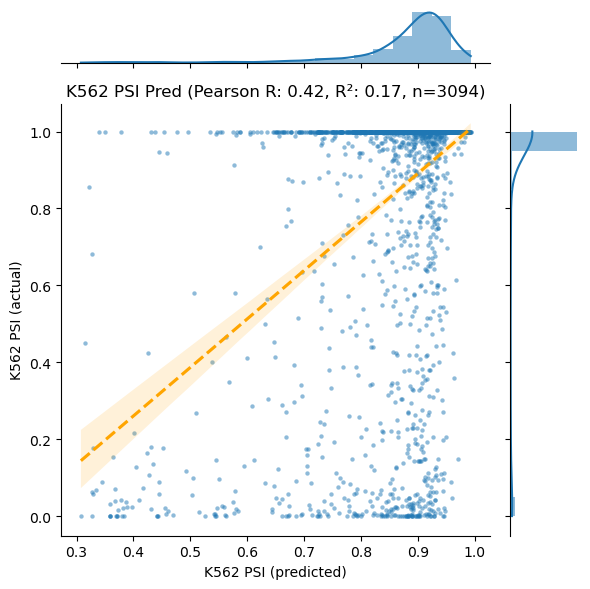

In [129]:
if binary_predictions is not None:
    plot_confusion_matrix(binary_predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
    plt.show()

if predictions_psi_filtered is None:
    predictions_psi_filtered = predictions[predictions['gene_id'].isin(se_genes)] if FILTER_SE_GENES else predictions.copy()
plot_predictions(predictions_psi_filtered, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
plt.show()

In [130]:
if NORMALISED_SCORES:
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredPsi', actual_col='UncorrActualPsi')
    plt.show()
    plot_predictions(predictions_filtered, cell_line='K562', pred_col='UncorrPredExpr', actual_col='UncorrActualExpr')
    plt.show()

## Check how similar predictions for the same genes are 

In [131]:
# filter for rows where gene_id appears more than once
predictions_multiple = predictions[predictions.duplicated(subset=['gene_id'], keep=False)]
predictions_multiple

,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx
0,ENSG00000002016,1.313719,1.010724,GM12878,0.898365,1.000000,1
1,ENSG00000002016,1.233347,1.010724,GM12878,0.920559,1.000000,1
2,ENSG00000002016,0.964811,1.010724,GM12878,0.728862,0.208000,1
3,ENSG00000002016,1.411281,1.010724,GM12878,0.845089,0.000000,1
4,ENSG00000003056,1.894137,1.940716,GM12878,0.915052,1.000000,1
...,...,...,...,...,...,...,...
3085,ENSG00000257218,1.863640,1.438384,GM12878,0.431418,0.180688,1
3086,ENSG00000257390,1.232909,-0.552842,GM12878,0.930214,1.000000,1
3087,ENSG00000257390,1.010207,-0.552842,GM12878,0.931165,1.000000,1
3088,ENSG00000257390,1.210707,-0.552842,GM12878,0.881705,1.000000,1


In [132]:
predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()
predictions_multiple

/tmp/ipykernel_3948663/27208789.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predictions_multiple['index'] = predictions_multiple.groupby('gene_id').cumcount()


,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx,index
0,ENSG00000002016,1.313719,1.010724,GM12878,0.898365,1.000000,1,0
1,ENSG00000002016,1.233347,1.010724,GM12878,0.920559,1.000000,1,1
2,ENSG00000002016,0.964811,1.010724,GM12878,0.728862,0.208000,1,2
3,ENSG00000002016,1.411281,1.010724,GM12878,0.845089,0.000000,1,3
4,ENSG00000003056,1.894137,1.940716,GM12878,0.915052,1.000000,1,0
...,...,...,...,...,...,...,...,...
3085,ENSG00000257218,1.863640,1.438384,GM12878,0.431418,0.180688,1,1
3086,ENSG00000257390,1.232909,-0.552842,GM12878,0.930214,1.000000,1,0
3087,ENSG00000257390,1.010207,-0.552842,GM12878,0.931165,1.000000,1,1
3088,ENSG00000257390,1.210707,-0.552842,GM12878,0.881705,1.000000,1,2


In [133]:
summary = (
    predictions_multiple
    .groupby('gene_id')['PredExpr']
    .agg(['min', 'max', 'mean'])
    .assign(range=lambda x: x['max'] - x['min'])
    .sort_values('mean', ascending=False)
    .reset_index()
)
summary

,gene_id,min,max,mean,range
0,ENSG00000135486,2.191896,2.211845,2.201871,0.019949
1,ENSG00000111481,2.075143,2.194422,2.154784,0.119280
2,ENSG00000092841,2.044658,2.183342,2.149337,0.138684
3,ENSG00000215021,2.052528,2.165024,2.133676,0.112497
4,ENSG00000143933,1.985975,2.171277,2.082373,0.185302
...,...,...,...,...,...
799,ENSG00000139044,-0.631631,-0.620633,-0.627675,0.010997
800,ENSG00000163082,-0.704559,-0.680105,-0.692332,0.024455
801,ENSG00000186854,-0.734303,-0.667703,-0.701003,0.066600
802,ENSG00000091428,-0.717452,-0.715967,-0.716710,0.001484


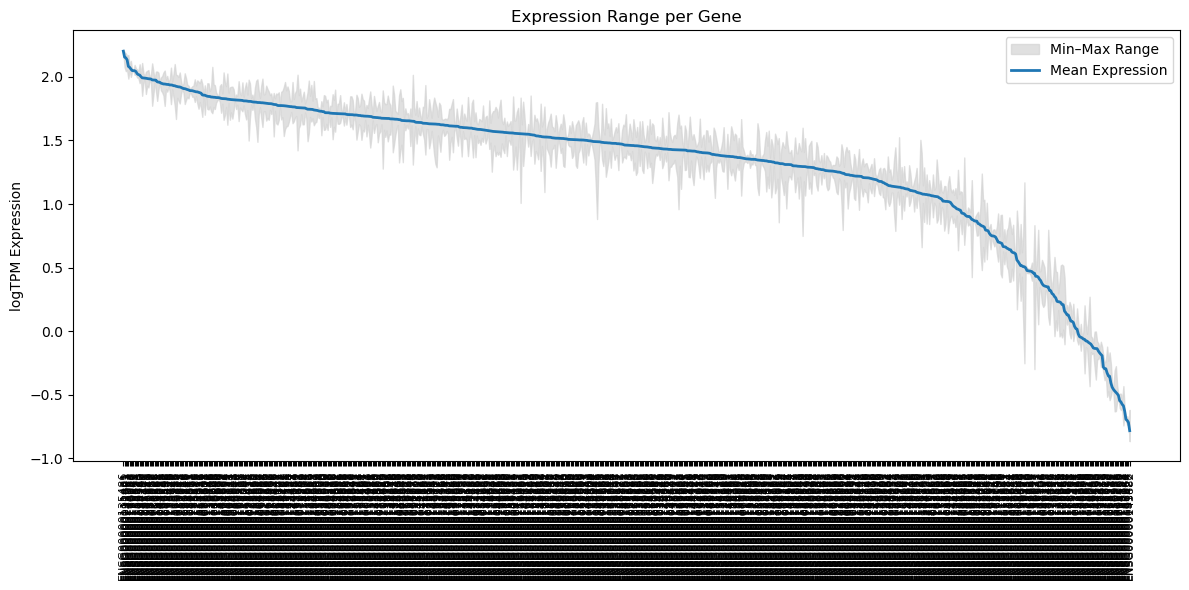

In [134]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(summary))

# Shaded area for min-max range
ax.fill_between(x, summary['min'], summary['max'], color='lightgray', alpha=0.7, label='Min–Max Range')

# Line for the mean
ax.plot(x, summary['mean'], linewidth=2, label='Mean Expression')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(summary['gene_id'], rotation=90, fontsize=8)
ax.set_ylabel("logTPM Expression")
ax.set_title("Expression Range per Gene")
ax.legend()
plt.tight_layout()
plt.show()

## Binary output

In [135]:
# remove rows where ActualPsi is > 0.2 and < 0.8
predictions_filtered = predictions[(predictions['ActualPsi'] <= 0.2) | (predictions['ActualPsi'] >= 0.8)].copy()
predictions_filtered

,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx
0,ENSG00000002016,1.313719,1.010724,GM12878,0.898365,1.0,1
1,ENSG00000002016,1.233347,1.010724,GM12878,0.920559,1.0,1
3,ENSG00000002016,1.411281,1.010724,GM12878,0.845089,0.0,1
4,ENSG00000003056,1.894137,1.940716,GM12878,0.915052,1.0,1
5,ENSG00000003056,1.995130,1.940716,GM12878,0.922118,1.0,1
...,...,...,...,...,...,...,...
3089,ENSG00000257390,0.846377,-0.552842,GM12878,0.893040,1.0,1
3090,ENSG00000257727,1.605636,2.163400,GM12878,0.925916,1.0,1
3091,ENSG00000257921,1.830481,-0.136677,GM12878,0.676849,1.0,1
3092,ENSG00000258311,1.615263,0.096910,GM12878,0.892272,1.0,1


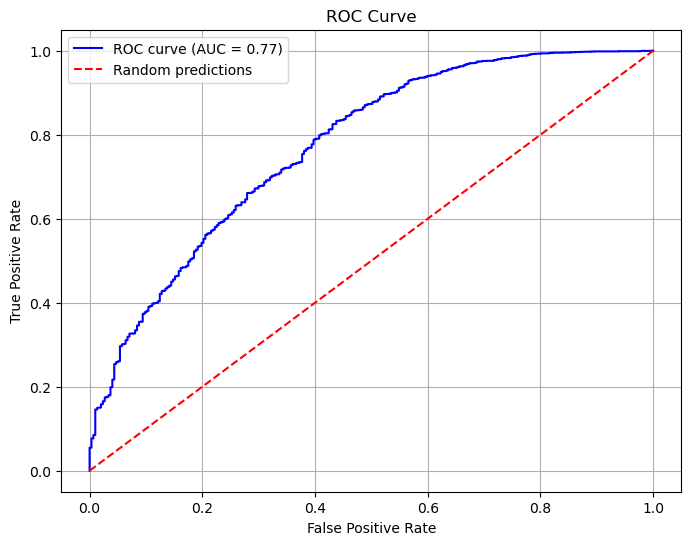

In [136]:
# binarize ActualPsi
predictions_filtered['BinarizedPsi'] = np.where(predictions_filtered['ActualPsi'] >= 0.5, 1, 0)
# plot ROC
fpr, tpr, thresholds = roc_curve(predictions_filtered['BinarizedPsi'], predictions_filtered['PredPsi'])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random predictions')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid()
plt.legend()
plt.show()

In [137]:
# print f1, accuracy, precision, recall
from sklearn.metrics import matthews_corrcoef, roc_auc_score, balanced_accuracy_score
predictions_filtered['BinarizedPsi'] = np.where(predictions_filtered['ActualPsi'] >= 0.5, 0, 1)
predictions_filtered['BinarizedPred'] = np.where(predictions_filtered['PredPsi'] >= 0.7, 0, 1)

mcc = matthews_corrcoef(predictions_filtered['BinarizedPsi'], predictions_filtered['BinarizedPred'])
roc_auc = roc_auc_score(predictions_filtered['BinarizedPsi'], predictions_filtered['BinarizedPred'])
balanced_acc = balanced_accuracy_score(predictions_filtered['BinarizedPsi'], predictions_filtered['BinarizedPred'])
print(f"MCC: {mcc:.2f}, ROC AUC: {roc_auc:.2f}, Balanced Accuracy: {balanced_acc:.2f}")

MCC: 0.36, ROC AUC: 0.63, Balanced Accuracy: 0.63


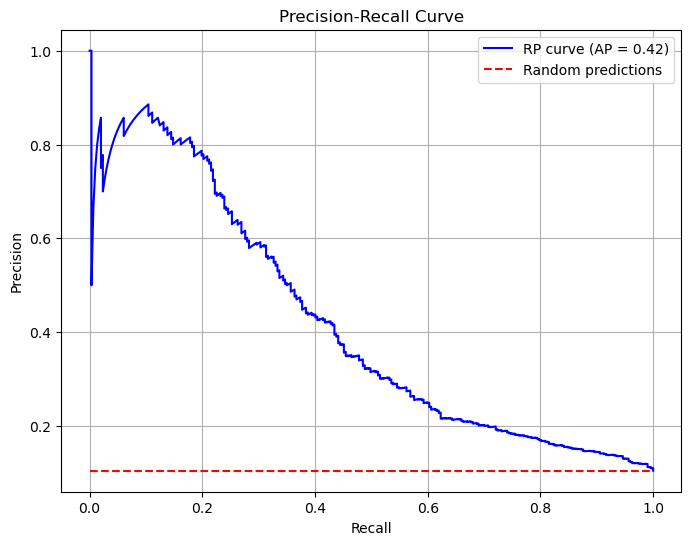

In [138]:
# binarize ActualPsi
# plot Precision recall curve
precision, recall, thresholds = precision_recall_curve(predictions_filtered['BinarizedPsi'], predictions_filtered['PredPsi'] * -1)
average_precision = average_precision_score(predictions_filtered['BinarizedPsi'], predictions_filtered['PredPsi'] * -1)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label=f'RP curve (AP = {average_precision:.2f})')
plt.hlines(sum(predictions_filtered['BinarizedPsi']) / len(predictions_filtered['BinarizedPsi']), 0, 1, colors='red', linestyles='dashed', label='Random predictions')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()
plt.legend()
plt.show()

In [139]:
predictions_filtered

,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx,BinarizedPsi,BinarizedPred
0,ENSG00000002016,1.313719,1.010724,GM12878,0.898365,1.0,1,0,0
1,ENSG00000002016,1.233347,1.010724,GM12878,0.920559,1.0,1,0,0
3,ENSG00000002016,1.411281,1.010724,GM12878,0.845089,0.0,1,1,0
4,ENSG00000003056,1.894137,1.940716,GM12878,0.915052,1.0,1,0,0
5,ENSG00000003056,1.995130,1.940716,GM12878,0.922118,1.0,1,0,0
...,...,...,...,...,...,...,...,...,...
3089,ENSG00000257390,0.846377,-0.552842,GM12878,0.893040,1.0,1,0,0
3090,ENSG00000257727,1.605636,2.163400,GM12878,0.925916,1.0,1,0,0
3091,ENSG00000257921,1.830481,-0.136677,GM12878,0.676849,1.0,1,0,1
3092,ENSG00000258311,1.615263,0.096910,GM12878,0.892272,1.0,1,0,0


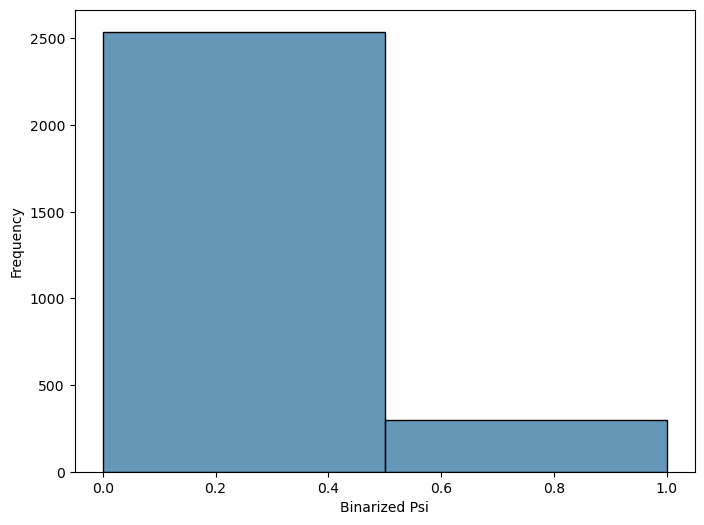

In [140]:
# plot distribution of binary samples as hist plot
plt.figure(figsize=(8, 6))
sns.histplot(predictions_filtered['BinarizedPsi'], bins=2, color='#3274A1', kde=False)
plt.xlabel('Binarized Psi')
plt.ylabel('Frequency')
plt.show()

## Check predictions of AR vs SE genes in expression

In [141]:
predictions_split = predictions.copy()
se_events = pd.read_csv('../data/psi_response.csv')
se_events = se_events[se_events['event_id'].str.contains(';SE:')]
se_genes = set(se_events['gene_id'].unique())

predictions_split['SE gene'] = predictions_split['gene_id'].apply(lambda x: x in se_genes)
predictions_split['AR gene'] = ~predictions_split['SE gene']
predictions_split

,gene_id,PredExpr,ActualExpr,CellLine,PredPsi,ActualPsi,fold_idx,SE gene,AR gene
0,ENSG00000002016,1.313719,1.010724,GM12878,0.898365,1.000,1,True,False
1,ENSG00000002016,1.233347,1.010724,GM12878,0.920559,1.000,1,True,False
2,ENSG00000002016,0.964811,1.010724,GM12878,0.728862,0.208,1,True,False
3,ENSG00000002016,1.411281,1.010724,GM12878,0.845089,0.000,1,True,False
4,ENSG00000003056,1.894137,1.940716,GM12878,0.915052,1.000,1,False,True
...,...,...,...,...,...,...,...,...,...
3089,ENSG00000257390,0.846377,-0.552842,GM12878,0.893040,1.000,1,False,True
3090,ENSG00000257727,1.605636,2.163400,GM12878,0.925916,1.000,1,False,True
3091,ENSG00000257921,1.830481,-0.136677,GM12878,0.676849,1.000,1,False,True
3092,ENSG00000258311,1.615263,0.096910,GM12878,0.892272,1.000,1,False,True


<Figure size 600x600 with 0 Axes>

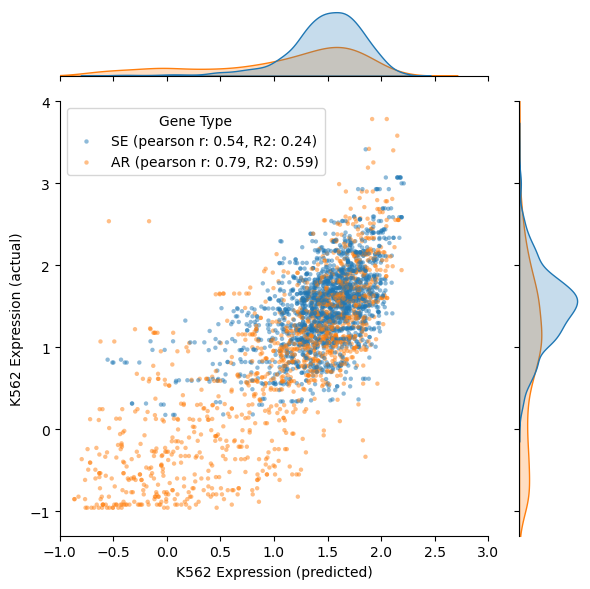

In [142]:
# visualise predictions of expr by SE gene (also calculate metrics by SE gene)

se_preds = predictions_split[predictions_split['SE gene'] == True]
ar_preds = predictions_split[predictions_split['SE gene'] == False]
pearsonR_se, _ = stats.pearsonr(se_preds['PredExpr'], se_preds['ActualExpr'])
pearsonR_ar, _ = stats.pearsonr(ar_preds['PredExpr'], ar_preds['ActualExpr'])
r2_se = r2_score(se_preds['ActualExpr'], se_preds['PredExpr'])
r2_ar = r2_score(ar_preds['ActualExpr'], ar_preds['PredExpr'])
prediction_task = 'Expression'

predictions_split['Gene Type'] = predictions_split['SE gene'].replace({True: f'SE (pearson r: {pearsonR_se:.2f}, R2: {r2_se:.2f})', False: f'AR (pearson r: {pearsonR_ar:.2f}, R2: {r2_ar:.2f})'})

plt.figure(figsize=(6,6))
ax = sns.jointplot(
    data=predictions_split,
    x='PredExpr',
    y='ActualExpr',
    hue='Gene Type',
    kind = 'scatter',
    joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
)

plt.ylabel(f'{cell_line} {prediction_task} (actual)')
plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
plt.ylim(-1.3,4)
plt.xlim(-1,3)
plt.tight_layout()
plt.show()